In [18]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from project_paths import RAW_DIR
from src.data_manage.load_data import load_csv, load_excel, list_raw_files
from src.utils.eda import quick_eda, missing_summary, uniqueness_summary

from project_paths import PROCESSED_DIR

import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np  

import seaborn as sns   
from pandas.api.types import is_numeric_dtype, is_bool_dtype


In [3]:
csv_files = list_raw_files("*.csv")
[file.relative_to(RAW_DIR) for file in csv_files]

[WindowsPath('Agriculture Crop Yield/crop_yield.csv'),
 WindowsPath('Crop Yield Prediction Dataset/pesticides.csv'),
 WindowsPath('Crop Yield Prediction Dataset/rainfall.csv'),
 WindowsPath('Crop Yield Prediction Dataset/temp.csv'),
 WindowsPath('Crop Yield Prediction Dataset/yield.csv'),
 WindowsPath('Crop Yield Prediction Dataset/yield_df.csv')]

In [4]:
for file in csv_files:
    rel_path = file.relative_to(RAW_DIR)
    df = load_csv(rel_path)
    print("=" * 100)
    print(f"Fichier : {rel_path}")
    print(f"Shape : {df.shape}")
    print(f"Colonnes : {df.columns.tolist()}")

Fichier : Agriculture Crop Yield\crop_yield.csv
Shape : (1000000, 10)
Colonnes : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']
Fichier : Crop Yield Prediction Dataset\pesticides.csv
Shape : (4349, 7)
Colonnes : ['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value']
Fichier : Crop Yield Prediction Dataset\rainfall.csv
Shape : (6727, 3)
Colonnes : [' Area', 'Year', 'average_rain_fall_mm_per_year']
Fichier : Crop Yield Prediction Dataset\temp.csv
Shape : (71311, 3)
Colonnes : ['year', 'country', 'avg_temp']
Fichier : Crop Yield Prediction Dataset\yield.csv
Shape : (56717, 12)
Colonnes : ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']
Fichier : Crop Yield Prediction Dataset\yield_df.csv
Shape : (28242, 8)
Colonnes : ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'av

In [5]:
for file in csv_files:
    rel_path = file.relative_to(RAW_DIR)
    df = load_csv(rel_path)
    print("=" * 100)
    print(f"Fichier : {rel_path}")
    display(df.head(20))

Fichier : Agriculture Crop Yield\crop_yield.csv


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
5,South,Silt,Soybean,797.471182,37.704974,False,True,Rainy,74,5.898416
6,West,Clay,Wheat,357.902357,31.593431,False,False,Rainy,90,2.652392
7,South,Sandy,Rice,441.131154,30.887107,True,True,Sunny,61,5.829542
8,North,Silt,Wheat,181.587861,26.752729,True,False,Sunny,127,2.943716
9,West,Sandy,Wheat,395.048968,17.646199,False,True,Rainy,140,3.707293


Fichier : Crop Yield Prediction Dataset\pesticides.csv


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.00
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.00
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.00
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.00
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.00
5,Pesticides Use,Albania,Use,Pesticides (total),1995,tonnes of active ingredients,251.00
6,Pesticides Use,Albania,Use,Pesticides (total),1996,tonnes of active ingredients,313.96
7,Pesticides Use,Albania,Use,Pesticides (total),1997,tonnes of active ingredients,376.93
8,Pesticides Use,Albania,Use,Pesticides (total),1998,tonnes of active ingredients,439.89
9,Pesticides Use,Albania,Use,Pesticides (total),1999,tonnes of active ingredients,502.86


Fichier : Crop Yield Prediction Dataset\rainfall.csv


...

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN
5,1854,Côte D'Ivoire,NaN
6,1855,Côte D'Ivoire,NaN
7,1856,Côte D'Ivoire,26.28
8,1857,Côte D'Ivoire,25.17
9,1858,Côte D'Ivoire,25.49


Fichier : Crop Yield Prediction Dataset\yield.csv


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400
5,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1966,1966,hg/ha,14400
6,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1967,1967,hg/ha,14144
7,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1968,1968,hg/ha,17064
8,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1969,1969,hg/ha,17177
9,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1970,1970,hg/ha,14757


Fichier : Crop Yield Prediction Dataset\yield_df.csv


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37
5,5,Albania,Wheat,1990,30197,1485.0,121.0,16.37
6,6,Albania,Maize,1991,29068,1485.0,121.0,15.36
7,7,Albania,Potatoes,1991,77818,1485.0,121.0,15.36
8,8,Albania,"Rice, paddy",1991,28538,1485.0,121.0,15.36
9,9,Albania,Sorghum,1991,6667,1485.0,121.0,15.36


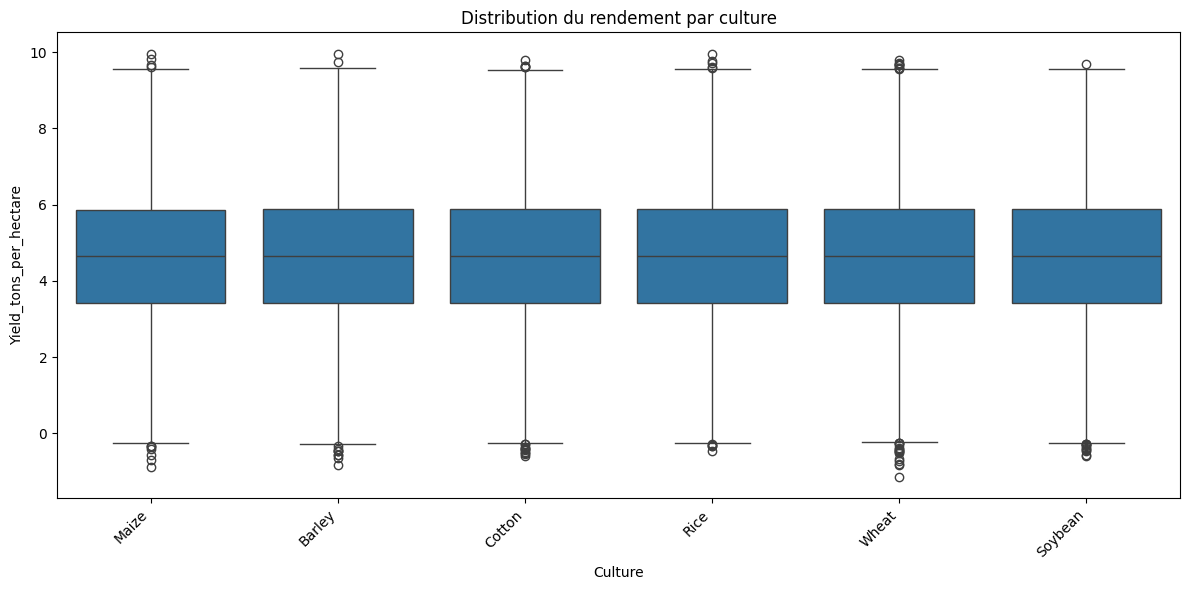

In [13]:
# ==========================================
# Distribution des rendements par culture
# ==========================================

crop_aux = load_csv("Agriculture Crop Yield/crop_yield.csv")
target = "Yield_tons_per_hectare"  

plot_df = (
    crop_aux[["Crop", "Yield_tons_per_hectare"]]
    .dropna()
    .copy()
)

# ordre des cultures selon la médiane du rendement
crop_order = (
    plot_df.groupby("Crop")["Yield_tons_per_hectare"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x="Crop",
    y="Yield_tons_per_hectare",
    order=crop_order
)

plt.title("Distribution du rendement par culture")
plt.xlabel("Culture")
plt.ylabel("Yield_tons_per_hectare")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

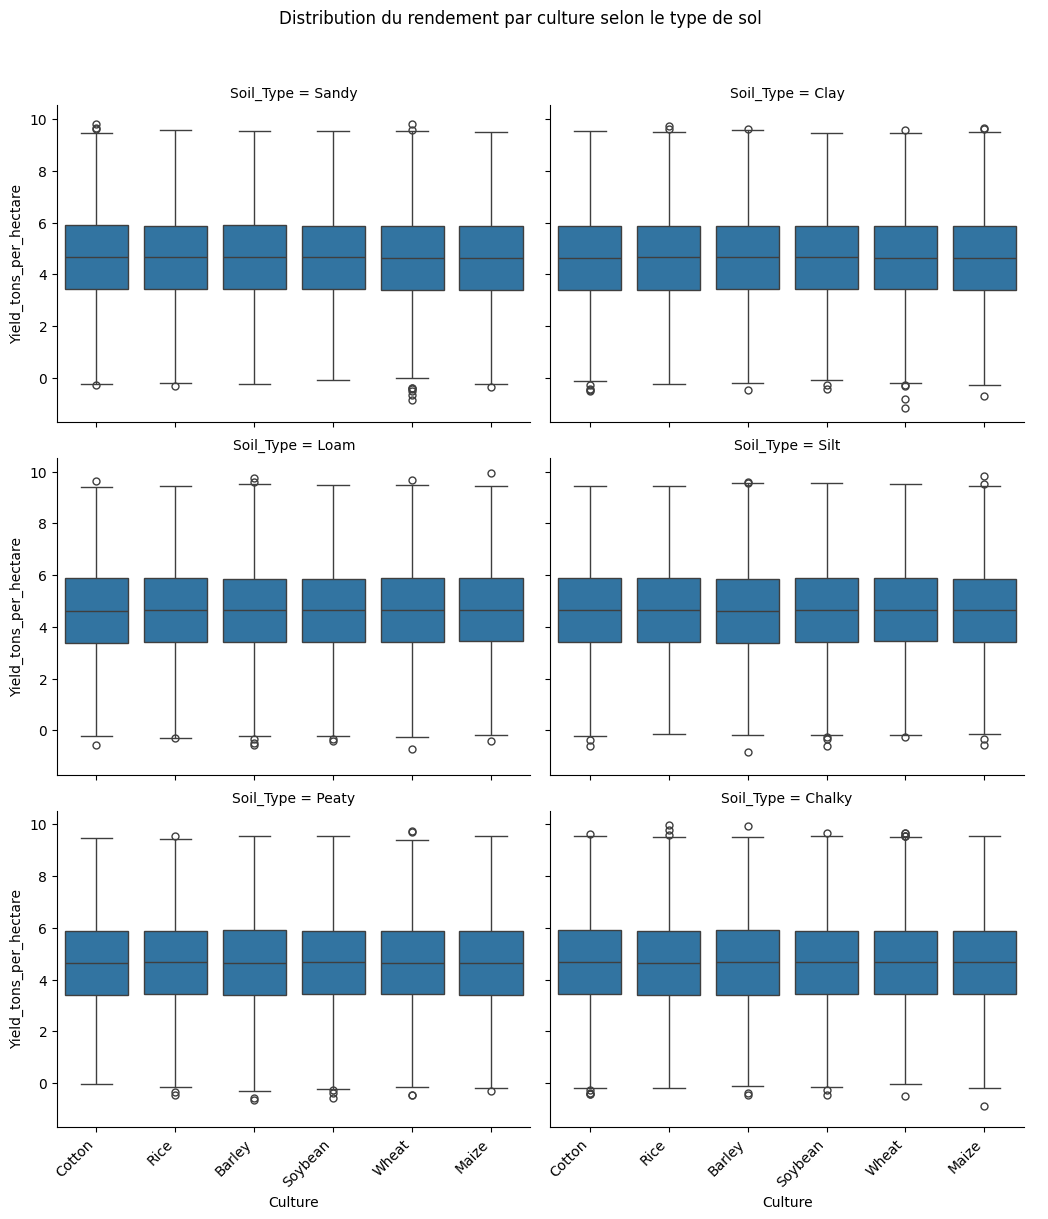

In [14]:
plot_df = crop_aux[["Crop", "Soil_Type", target]].dropna().copy()

g = sns.catplot(
    data=plot_df,
    x="Crop",
    y=target,
    col="Soil_Type",
    kind="box",
    col_wrap=2,
    sharey=True,
    height=4,
    aspect=1.3
)

g.set_titles("Soil_Type = {col_name}")
g.set_axis_labels("Culture", "Yield_tons_per_hectare")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Distribution du rendement par culture selon le type de sol")
plt.show()

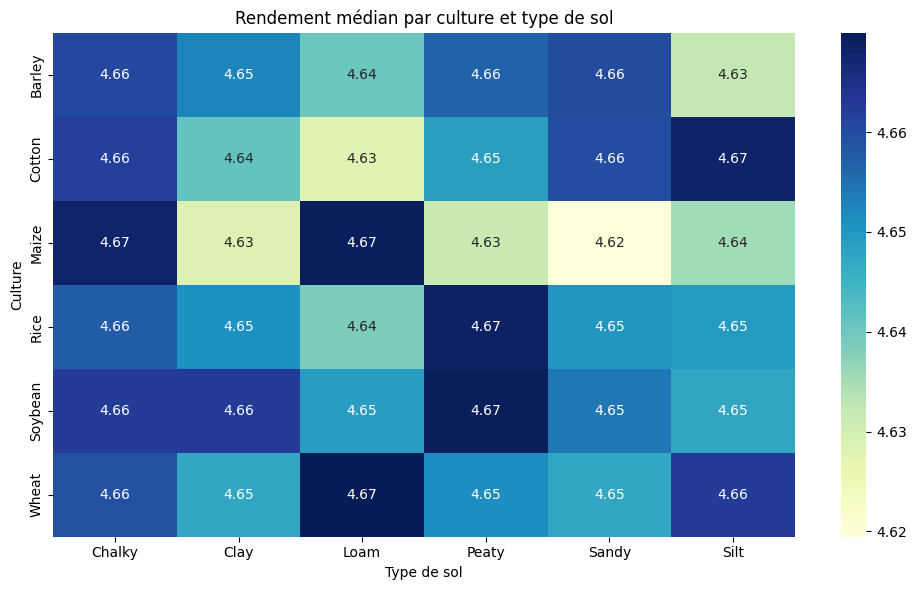

In [15]:
plot_df = crop_aux[["Crop", "Soil_Type", target]].dropna().copy()

heatmap_df = (
    plot_df.groupby(["Crop", "Soil_Type"], observed=False)[target]
    .median()
    .unstack()
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Rendement médian par culture et type de sol")
plt.xlabel("Type de sol")
plt.ylabel("Culture")
plt.tight_layout()
plt.show()

In [19]:
features_to_plot = [
    "Region",
    "Soil_Type",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
]

def plot_crop_feature_yield_heatmap(
    df,
    feature,
    target="Yield_tons_per_hectare",
    agg="median",
    n_bins=6,
    max_categories=12,
    figsize=(10, 6)
):
    data = df[["Crop", feature, target]].dropna().copy()

    if data.empty:
        print(f"Aucune donnée exploitable pour {feature}")
        return

    plot_feature = feature

    # Cas booléen
    if is_bool_dtype(data[feature]):
        data[feature] = data[feature].map({True: "True", False: "False"})

    # Cas numérique : on crée des classes
    elif is_numeric_dtype(data[feature]):
        n_unique = data[feature].nunique()
        bins = min(n_bins, n_unique)

        if bins < 2:
            print(f"Pas assez de diversité pour binner {feature}")
            return

        plot_feature = f"{feature}_bin"
        data[plot_feature] = pd.qcut(
            data[feature],
            q=bins,
            duplicates="drop"
        ).astype(str)

    # Cas catégoriel : on limite au top catégories si besoin
    else:
        data[feature] = data[feature].astype(str)
        top_categories = data[feature].value_counts().head(max_categories).index
        data = data[data[feature].isin(top_categories)].copy()

    agg_df = (
        data.groupby(["Crop", plot_feature], observed=False)[target]
        .agg(agg)
        .reset_index()
    )

    pivot_df = agg_df.pivot(index="Crop", columns=plot_feature, values=target)

    plt.figure(figsize=figsize)
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"Rendement {agg} par culture et {feature}")
    plt.xlabel(feature if plot_feature == feature else f"{feature} (classes)")
    plt.ylabel("Crop")
    plt.tight_layout()
    plt.show()

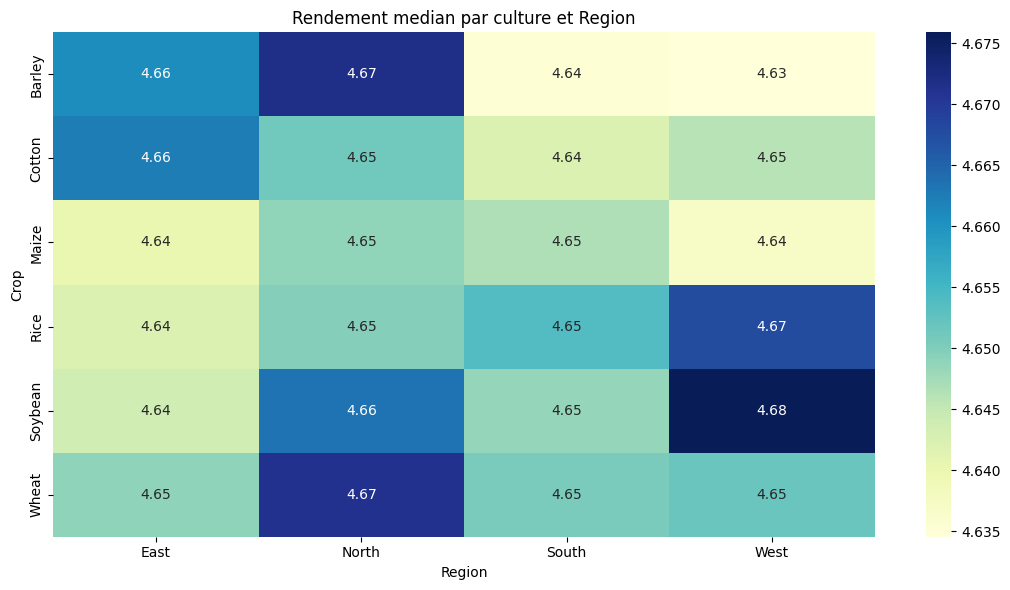

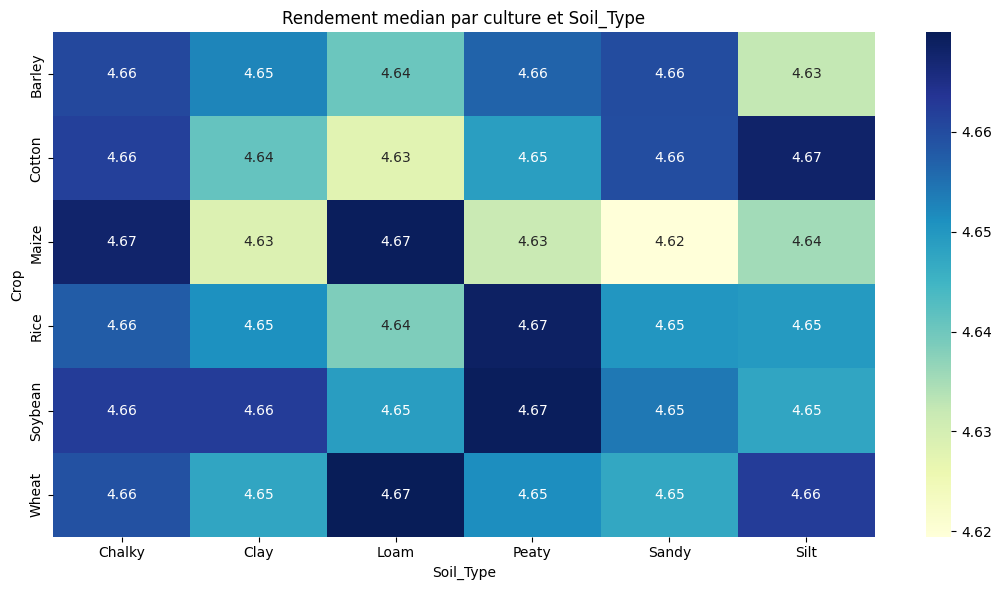

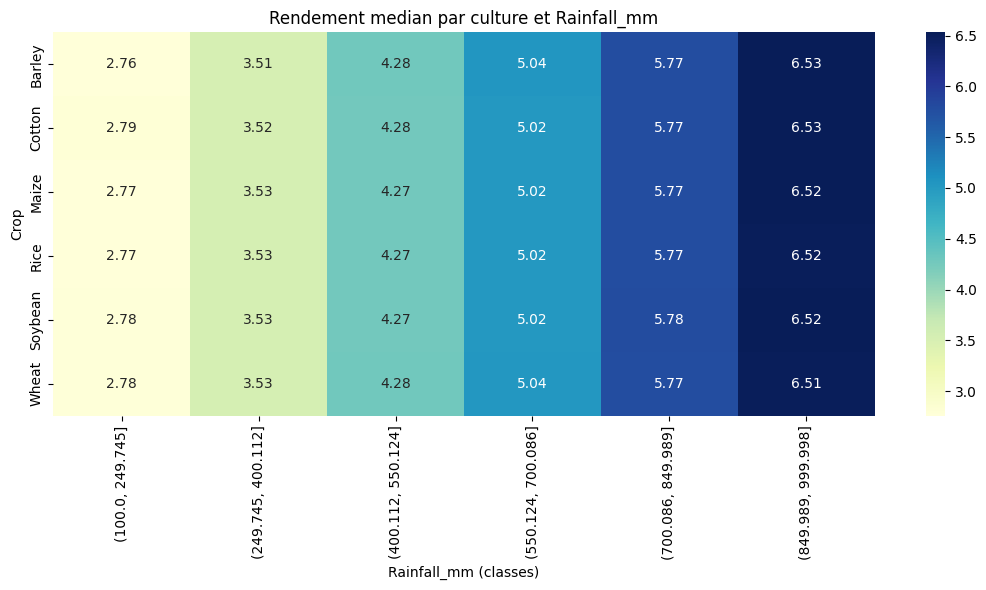

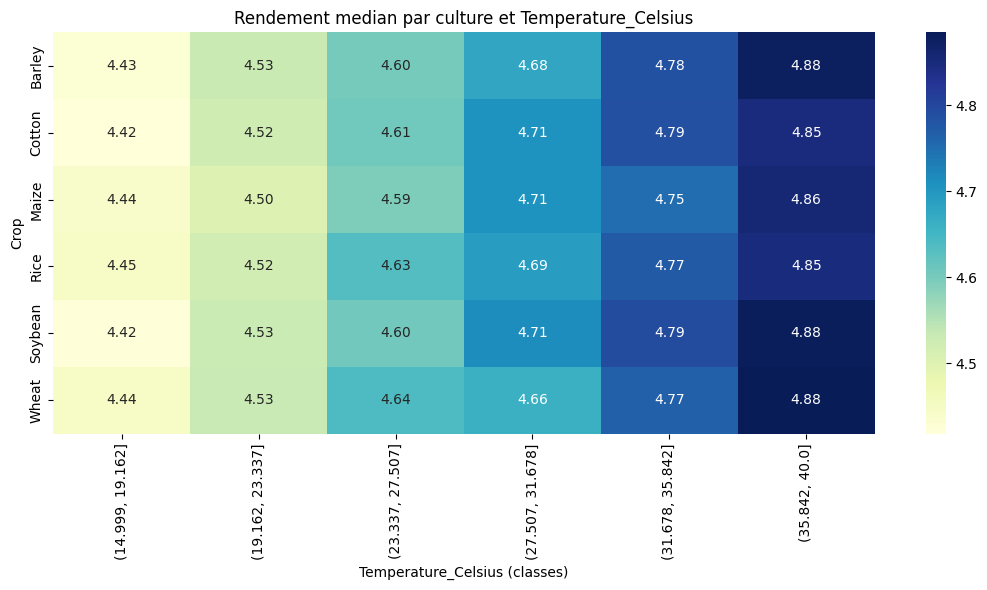

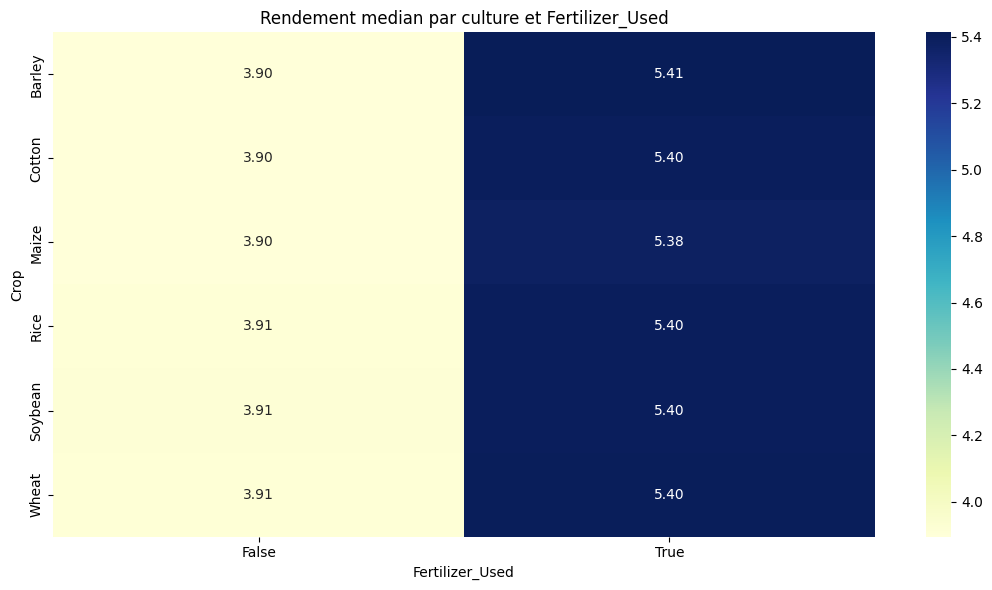

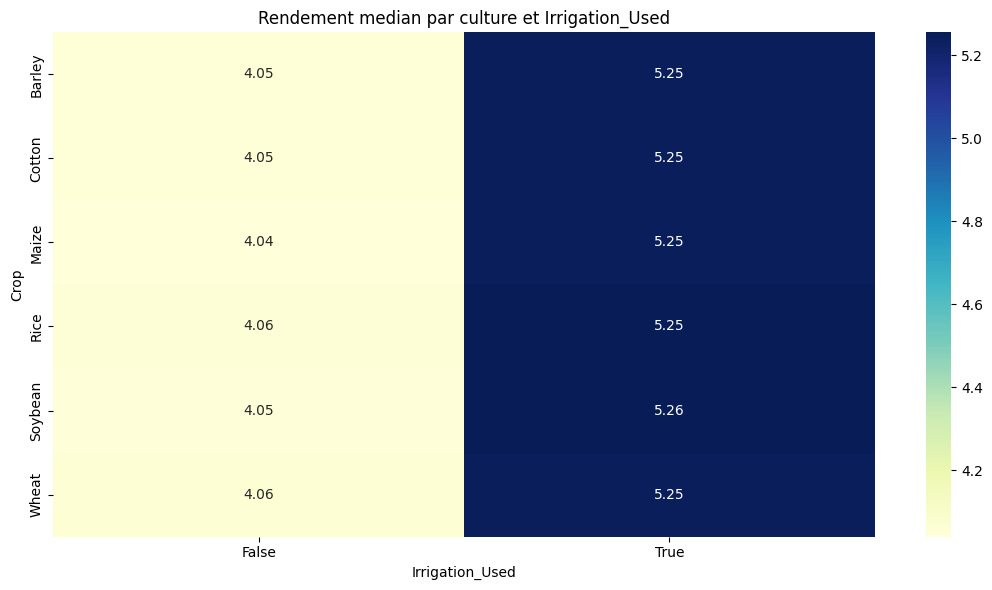

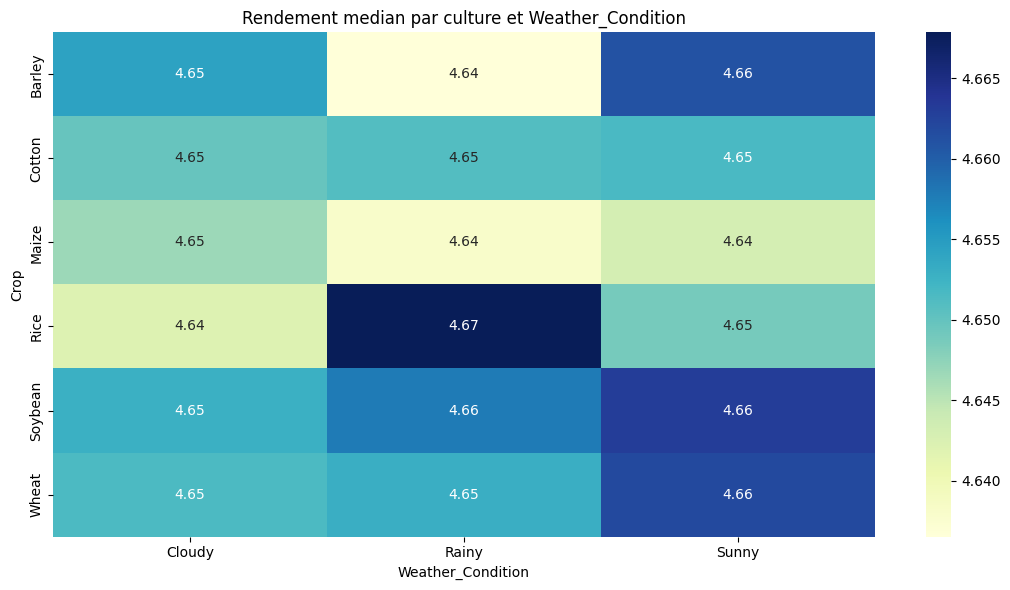

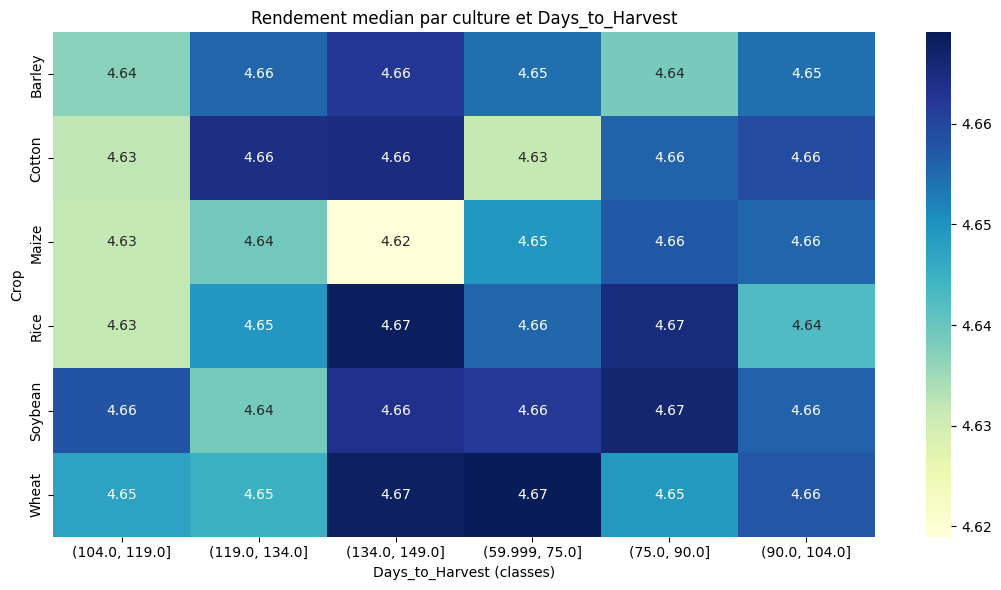

In [20]:
for feature in features_to_plot:
    plot_crop_feature_yield_heatmap(
        df=crop_aux,
        feature=feature,
        target="Yield_tons_per_hectare",
        agg="median",   # tu peux mettre "mean" si tu préfères
        n_bins=6,
        max_categories=12,
        figsize=(11, 6)
    )

In [ ]:
yield_df_raw = load_csv("Crop Yield Prediction Dataset/yield.csv")
yield_df_raw[["Area", "Item", "Year"]].duplicated().sum()

np.int64(0)

In [ ]:
pest_df = load_csv("Crop Yield Prediction Dataset/pesticides.csv")
pest_df[["Area", "Year"]].duplicated().sum()

np.int64(0)

In [ ]:
rain_df = load_csv("Crop Yield Prediction Dataset/rainfall.csv")
rain_df = rain_df.rename(columns={" Area": "Area"})
rain_df[["Area", "Year"]].duplicated().sum()

np.int64(0)

In [ ]:
temp_df = load_csv("Crop Yield Prediction Dataset/temp.csv")
temp_df = temp_df.rename(columns={"country": "Area", "year": "Year"})
temp_df[["Area", "Year"]].duplicated().sum()

np.int64(42797)

In [ ]:
for name, df, cols in [
    ("yield", yield_df_raw, ["Area", "Item", "Year"]),
    ("pesticides", pest_df, ["Area", "Year"]),
    ("rainfall", rain_df, ["Area", "Year"]),
    ("temp", temp_df, ["Area", "Year"]),
]:
    print("=" * 80)
    print(name)
    for col in cols:
        print(col, df[col].nunique())

yield
Area 212
Item 10
Year 56
pesticides
Area 168
Year 27
rainfall
Area 217
Year 31
temp
Area 137
Year 271


In [ ]:
yield_merged = load_csv("Crop Yield Prediction Dataset/yield_df.csv")
display(yield_merged.head())
print(yield_merged.columns.tolist())

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [ ]:
yield_raw = load_csv("Crop Yield Prediction Dataset/yield.csv")
pest_raw = load_csv("Crop Yield Prediction Dataset/pesticides.csv")
rain_raw = load_csv("Crop Yield Prediction Dataset/rainfall.csv")
temp_raw = load_csv("Crop Yield Prediction Dataset/temp.csv")
yield_ref = load_csv("Crop Yield Prediction Dataset/yield_df.csv")
crop_aux = load_csv("Agriculture Crop Yield/crop_yield.csv")

In [ ]:
#Affichage des informations selon le type de variable qualitatives ou quantitaves
print("### Yield DataFrame\n")
for col in yield_df_raw.columns:
    print(f"### Colonne : {col}\n")
        
    if yield_df_raw[col].dtype == "object" or str(yield_df_raw[col].dtype) == "category":
        print("Variable qualitative\n")
        print(yield_df_raw[col].value_counts(dropna=False))
    else:
        print("Variable quantitative\n")
        print(yield_df_raw[col].describe())
        
    print("\n" + "-"*50 + "\n")

print("### Pesticides DataFrame\n")
for col in pest_df.columns:
    print(f"### Colonne : {col}\n")
        
    if pest_df[col].dtype == "object" or str(pest_df[col].dtype) == "category":
        print("Variable qualitative\n")
        print(pest_df[col].value_counts(dropna=False))
    else:
        print("Variable quantitative\n")
        print(pest_df[col].describe())
        
    print("\n" + "-"*50 + "\n")

print("### Rainfall DataFrame\n")
for col in rain_df.columns:
    print(f"### Colonne : {col}\n")
        
    if rain_df[col].dtype == "object" or str(rain_df[col].dtype) == "category":
        print("Variable qualitative\n")
        print(rain_df[col].value_counts(dropna=False))
    else:
        print("Variable quantitative\n")
        print(rain_df[col].describe())
        
    print("\n" + "-"*50 + "\n")

print("### Temp DataFrame\n")
for col in temp_df.columns:
    print(f"### Colonne : {col}\n")
        
    if temp_df[col].dtype == "object" or str(temp_df[col].dtype) == "category":
        print("Variable qualitative\n")
        print(temp_df[col].value_counts(dropna=False))
    else:
        print("Variable quantitative\n")
        print(temp_df[col].describe())
        
    print("\n" + "-"*50 + "\n")

print("### Crop_aux DataFrame\n")
for col in crop_aux.columns:
    print(f"### Colonne : {col}\n")
        
    if crop_aux[col].dtype == "object" or str(crop_aux[col].dtype) == "category":
        print("Variable qualitative\n")
        print(crop_aux[col].value_counts(dropna=False))
    else:
        print("Variable quantitative\n")
        print(crop_aux[col].describe())
        
    print("\n" + "-"*50 + "\n")

### Yield DataFrame

### Colonne : Domain Code

Variable qualitative

Domain Code
QC    56717
Name: count, dtype: int64

--------------------------------------------------

### Colonne : Domain

Variable qualitative

Domain
Crops    56717
Name: count, dtype: int64

--------------------------------------------------

### Colonne : Area Code

Variable quantitative

count    56717.000000
mean       125.650422
std         75.120195
min          1.000000
25%         58.000000
50%        122.000000
75%        184.000000
max        351.000000
Name: Area Code, dtype: float64

--------------------------------------------------

### Colonne : Area

Variable qualitative

Area
Democratic Republic of the Congo      560
Nigeria                               560
United Republic of Tanzania           560
Venezuela (Bolivarian Republic of)    532
Cameroon                              528
                                     ... 
Estonia                                50
Djibouti                        

In [ ]:
yield_clean = yield_raw.copy()
pest_clean = pest_raw.copy()
rain_clean = rain_raw.copy()
temp_clean = temp_raw.copy()

In [ ]:
yield_clean = yield_clean.rename(columns={"Value": "hg/ha_yield"})
yield_clean = yield_clean[["Area", "Item", "Year", "Unit", "hg/ha_yield"]].copy()

pest_clean = pest_clean.rename(columns={"Value": "pesticides_tonnes"})
pest_clean = pest_clean[["Area", "Year", "Unit", "pesticides_tonnes"]].copy()

rain_clean = rain_clean.rename(columns={" Area": "Area"})
rain_clean = rain_clean[["Area", "Year", "average_rain_fall_mm_per_year"]].copy()

temp_clean = temp_clean.rename(columns={"country": "Area", "year": "Year"})
temp_clean = temp_clean[["Area", "Year", "avg_temp"]].copy()


In [ ]:
temp_dupes = (
    temp_clean
    .groupby(["Area", "Year"])
    .agg(
        n_rows=("avg_temp", "size"),
        n_unique_temp=("avg_temp", "nunique"),
        temp_min=("avg_temp", "min"),
        temp_max=("avg_temp", "max"),
        temp_mean=("avg_temp", "mean"),
    )
    .reset_index()
)

temp_dupes[temp_dupes["n_rows"] > 1].head(20)

,Area,Year,n_rows,n_unique_temp,temp_min,temp_max,temp_mean
871,Argentina,1855,2,2,14.00,14.22,14.110
872,Argentina,1856,2,2,16.23,16.80,16.515
873,Argentina,1857,2,2,16.54,17.33,16.935
874,Argentina,1858,2,2,16.22,16.64,16.430
875,Argentina,1859,2,2,16.79,16.85,16.820
876,Argentina,1860,2,2,16.45,16.46,16.455
877,Argentina,1861,2,2,16.27,16.63,16.450
878,Argentina,1862,2,2,16.32,16.65,16.485
879,Argentina,1863,2,2,15.86,16.16,16.010
880,Argentina,1864,2,2,16.35,16.79,16.570


In [ ]:
temp_dupes["n_rows"].value_counts().sort_index().head(20)

n_rows
1     20520
2      3451
3      1192
4       197
5       791
6       742
7       191
8       190
9       375
10       13
11      178
15       11
20       20
22      214
27       10
29        7
31       45
34      173
37        5
38        3
Name: count, dtype: int64

In [ ]:
temp_dupes[temp_dupes["n_unique_temp"] > 1].head(20)

,Area,Year,n_rows,n_unique_temp,temp_min,temp_max,temp_mean
871,Argentina,1855,2,2,14.00,14.22,14.110
872,Argentina,1856,2,2,16.23,16.80,16.515
873,Argentina,1857,2,2,16.54,17.33,16.935
874,Argentina,1858,2,2,16.22,16.64,16.430
875,Argentina,1859,2,2,16.79,16.85,16.820
876,Argentina,1860,2,2,16.45,16.46,16.455
877,Argentina,1861,2,2,16.27,16.63,16.450
878,Argentina,1862,2,2,16.32,16.65,16.485
879,Argentina,1863,2,2,15.86,16.16,16.010
880,Argentina,1864,2,2,16.35,16.79,16.570


In [ ]:
temp_agg = (
    temp_clean
    .groupby(["Area", "Year"], as_index=False)
    .agg(avg_temp=("avg_temp", "mean"))
)

In [ ]:
temp_agg[["Area", "Year"]].duplicated().sum()

np.int64(0)

In [ ]:
areas_yield = set(yield_clean["Area"].astype(str).str.strip())
areas_pest = set(pest_clean["Area"].astype(str).str.strip())
areas_rain = set(rain_clean["Area"].astype(str).str.strip())
areas_temp = set(temp_agg["Area"].astype(str).str.strip())

print("Yield ∩ Pest:", len(areas_yield & areas_pest))
print("Yield ∩ Rain:", len(areas_yield & areas_rain))
print("Yield ∩ Temp:", len(areas_yield & areas_temp))

Yield ∩ Pest: 167
Yield ∩ Rain: 169
Yield ∩ Temp: 118


In [ ]:
years_yield = set(yield_clean["Year"])
years_pest = set(pest_clean["Year"])
years_rain = set(rain_clean["Year"])
years_temp = set(temp_agg["Year"])

print("Years Yield ∩ Pest:", len(years_yield & years_pest))
print("Years Yield ∩ Rain:", len(years_yield & years_rain))
print("Years Yield ∩ Temp:", len(years_yield & years_temp))

Years Yield ∩ Pest: 27
Years Yield ∩ Rain: 30
Years Yield ∩ Temp: 53


In [ ]:
merged = (
    yield_clean
    .merge(pest_clean[["Area", "Year", "pesticides_tonnes"]], on=["Area", "Year"], how="left")
    .merge(rain_clean[["Area", "Year", "average_rain_fall_mm_per_year"]], on=["Area", "Year"], how="left")
    .merge(temp_agg[["Area", "Year", "avg_temp"]], on=["Area", "Year"], how="left")
)

In [ ]:
merged.shape
merged.isna().sum().sort_values(ascending=False)

pesticides_tonnes                32564
average_rain_fall_mm_per_year    31317
avg_temp                         24507
Area                                 0
Unit                                 0
Year                                 0
Item                                 0
hg/ha_yield                          0
dtype: int64

In [ ]:
final_df = merged.dropna(
    subset=[
        "pesticides_tonnes",
        "average_rain_fall_mm_per_year",
        "avg_temp",
    ]
).copy()

In [ ]:
final_df.shape
print(final_df.head())
final_df.isna().sum()

        Area   Item  Year   Unit  hg/ha_yield  pesticides_tonnes  \
253  Albania  Maize  1990  hg/ha        36613              121.0   
254  Albania  Maize  1991  hg/ha        29068              121.0   
255  Albania  Maize  1992  hg/ha        24876              121.0   
256  Albania  Maize  1993  hg/ha        24185              121.0   
257  Albania  Maize  1994  hg/ha        25848              201.0   

    average_rain_fall_mm_per_year  avg_temp  
253                          1485     16.37  
254                          1485     15.36  
255                          1485     16.06  
256                          1485     16.05  
257                          1485     16.96  


Area                             0
Item                             0
Year                             0
Unit                             0
hg/ha_yield                      0
pesticides_tonnes                0
average_rain_fall_mm_per_year    0
avg_temp                         0
dtype: int64

In [ ]:
yield_ref_clean = yield_ref.drop(columns=["Unnamed: 0"]).copy()

In [ ]:
final_df.columns
yield_ref_clean.columns
final_df.shape
yield_ref_clean.shape

(28242, 7)

In [ ]:
final_df[["Area", "Item", "Year"]].duplicated().sum()
yield_ref_clean[["Area", "Item", "Year"]].duplicated().sum()

np.int64(15112)

In [ ]:
keys_final = set(map(tuple, final_df[["Area", "Item", "Year"]].to_numpy()))
keys_ref = set(map(tuple, yield_ref_clean[["Area", "Item", "Year"]].to_numpy()))

len(keys_final), len(keys_ref), len(keys_final & keys_ref)

(13136, 13130, 13130)

In [ ]:
final_df[[
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]].describe()

,hg/ha_yield,pesticides_tonnes,avg_temp
count,13136.000000,13136.000000,13136.000000
mean,70959.634440,14832.141503,19.839209
std,79111.427638,33646.165696,6.657741
min,50.000000,0.040000,1.300000
25%,18000.000000,264.582500,15.670000
50%,39536.000000,2170.400000,20.620000
75%,97159.000000,13335.220000,25.780000
max,501412.000000,367778.000000,30.420000


In [ ]:
yield_ref_clean[[
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]].describe()

,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.00000,28242.000000,28242.000000
mean,77053.332094,1149.05598,37076.909344,20.542627
std,84956.612897,709.81215,59958.784665,6.312051
min,50.000000,51.00000,0.040000,1.300000
25%,19919.250000,593.00000,1702.000000,16.702500
50%,38295.000000,1083.00000,17529.440000,21.510000
75%,104676.750000,1668.00000,48687.880000,26.000000
max,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:
print(final_df.shape)
print(yield_ref_clean.shape)

(13136, 8)
(28242, 7)


In [ ]:
extra_in_final = keys_final - keys_ref
len(extra_in_final), list(sorted(extra_in_final))[:10]

(6,
 [('Bahamas', 'Cassava', 1990),
  ('Bahamas', 'Cassava', 1991),
  ('Bahamas', 'Maize', 1990),
  ('Bahamas', 'Maize', 1991),
  ('Bahamas', 'Sweet potatoes', 1990),
  ('Bahamas', 'Sweet potatoes', 1991)])

In [ ]:
print("Doublons exacts :", yield_ref_clean.duplicated().sum())
print(
    "Doublons sur Area/Item/Year :",
    yield_ref_clean.duplicated(subset=["Area", "Item", "Year"]).sum()
)

Doublons exacts : 2310
Doublons sur Area/Item/Year : 15112


In [ ]:
yield_ref_clean[
    yield_ref_clean.duplicated(subset=["Area", "Item", "Year"], keep=False)
].sort_values(["Area", "Item", "Year"]).head(20)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
377,Argentina,Cassava,1990,100000,591.0,26156.00,17.46
378,Argentina,Cassava,1990,100000,591.0,26156.00,17.67
393,Argentina,Cassava,1991,100000,591.0,26156.00,17.64
394,Argentina,Cassava,1991,100000,591.0,26156.00,17.86
409,Argentina,Cassava,1992,100000,591.0,26156.00,17.09
410,Argentina,Cassava,1992,100000,591.0,26156.00,17.51
425,Argentina,Cassava,1993,100000,591.0,26156.00,17.32
426,Argentina,Cassava,1993,100000,591.0,26156.00,17.53
441,Argentina,Cassava,1994,100000,591.0,30195.00,18.17
442,Argentina,Cassava,1994,100000,591.0,30195.00,18.31


In [ ]:
final_df.head()

,Area,Item,Year,Unit,hg/ha_yield,pesticides_tonnes,average_rain_fall_mm_per_year,avg_temp
253,Albania,Maize,1990,hg/ha,36613,121.0,1485,16.37
254,Albania,Maize,1991,hg/ha,29068,121.0,1485,15.36
255,Albania,Maize,1992,hg/ha,24876,121.0,1485,16.06
256,Albania,Maize,1993,hg/ha,24185,121.0,1485,16.05
257,Albania,Maize,1994,hg/ha,25848,201.0,1485,16.96


In [ ]:
print(final_df["Year"].min(), final_df["Year"].max())

1990 2013


In [ ]:
final_df["Item"].value_counts().head(15)

Item
Potatoes                2091
Maize                   2030
Wheat                   1810
Rice, paddy             1502
Sorghum                 1435
Soybeans                1242
Sweet potatoes          1165
Cassava                  943
Plantains and others     464
Yams                     454
Name: count, dtype: int64

In [ ]:
final_df["Area"].value_counts().head(15)

Area
Cameroon       230
Kenya          230
Colombia       207
Brazil         207
Burundi        207
Peru           207
Rwanda         207
Mali           207
Uganda         207
Ecuador        207
Guatemala      204
Honduras       204
El Salvador    184
India          184
Madagascar     184
Name: count, dtype: int64

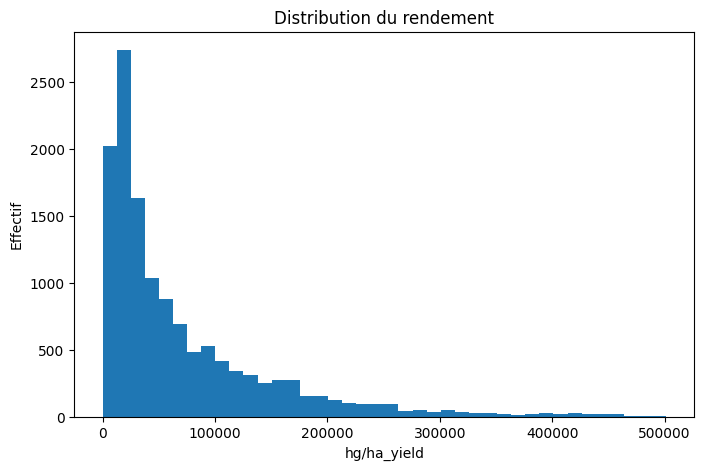

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(final_df["hg/ha_yield"], bins=40)
plt.xlabel("hg/ha_yield")
plt.ylabel("Effectif")
plt.title("Distribution du rendement")
plt.show()

In [ ]:
num_cols = [
    "Year",
    "hg/ha_yield",
    "pesticides_tonnes",
    "average_rain_fall_mm_per_year",
    "avg_temp",
]

for col in num_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

In [ ]:
for col in num_cols:
    print("=" * 60)
    print(col)
    print(final_df[col].dtype)
    print(final_df[col].astype(str).value_counts().head(10))

Year
int64
Year
2012    593
2013    592
2011    585
2010    585
2008    584
2006    583
2007    582
2009    582
2005    577
2004    577
Name: count, dtype: int64
hg/ha_yield
int64
hg/ha_yield
20000     71
10000     69
100000    62
50000     25
15000     25
40000     24
30000     21
60000     17
25000     16
18000     16
Name: count, dtype: int64
pesticides_tonnes
float64
pesticides_tonnes
88.0       162
1670.0     136
40.0       128
105.0      126
22.87      126
1597.0     120
1578.0     120
909.71     112
27.85      104
26857.0     91
Name: count, dtype: int64
average_rain_fall_mm_per_year
float64
average_rain_fall_mm_per_year
1604.0    230
630.0     230
3240.0    207
1761.0    207
1274.0    207
1738.0    207
1212.0    207
282.0     207
1180.0    207
2274.0    207
Name: count, dtype: int64
avg_temp
float64
avg_temp
27.2     49
27.28    38
27.23    37
19.79    37
19.85    36
27.12    35
19.93    34
27.8     33
27.79    32
27.01    31
Name: count, dtype: int64


In [ ]:
for col in num_cols:
    mask = final_df[col].astype(str).str.contains(r"\.\.", na=False)
    if mask.any():
        print(f"\nColonne problématique : {col}")
        display(final_df.loc[mask, ["Area", "Item", "Year", col]].head(20))

In [ ]:
final_df.to_csv(PROCESSED_DIR / "yield_dataset_consolidated.csv", index=False)

In [ ]:
# ==========================================
# Dataset annexe brut : pluie vs rendement par culture
# ==========================================

plot_annex_raw = final_df[[
    "Item",
    "average_rain_fall_mm_per_year",
    "hg/ha_yield",
]].dropna().copy()

# Conversion du rendement en tonnes/ha
plot_annex_raw["yield_t_ha"] = plot_annex_raw["hg/ha_yield"] / 10000.0

print("Nombre de lignes :", len(plot_annex_raw))
print("Nombre de cultures :", plot_annex_raw["Item"].nunique())

display(
    plot_annex_raw[[
        "average_rain_fall_mm_per_year",
        "yield_t_ha"
    ]].describe().T
)

Nombre de lignes : 13130
Nombre de cultures : 10


,count,mean,std,min,25%,50%,75%,max
average_rain_fall_mm_per_year,13130.0,1157.238766,743.622488,51.000,608.0,1083.00000,1651.000000,3240.0000
yield_t_ha,13130.0,7.096862,7.912428,0.005,1.8,3.95435,9.715225,50.1412


In [ ]:
top_n_crops = 12

top_items = (
    plot_annex_raw["Item"]
    .value_counts()
    .head(top_n_crops)
    .index
    .tolist()
)

plot_annex_top = plot_annex_raw[
    plot_annex_raw["Item"].isin(top_items)
].copy()

print("Cultures retenues :")
print(top_items)
print("Nombre de lignes retenues :", len(plot_annex_top))

Cultures retenues :
['Potatoes', 'Maize', 'Wheat', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Cassava', 'Plantains and others', 'Yams']
Nombre de lignes retenues : 13130


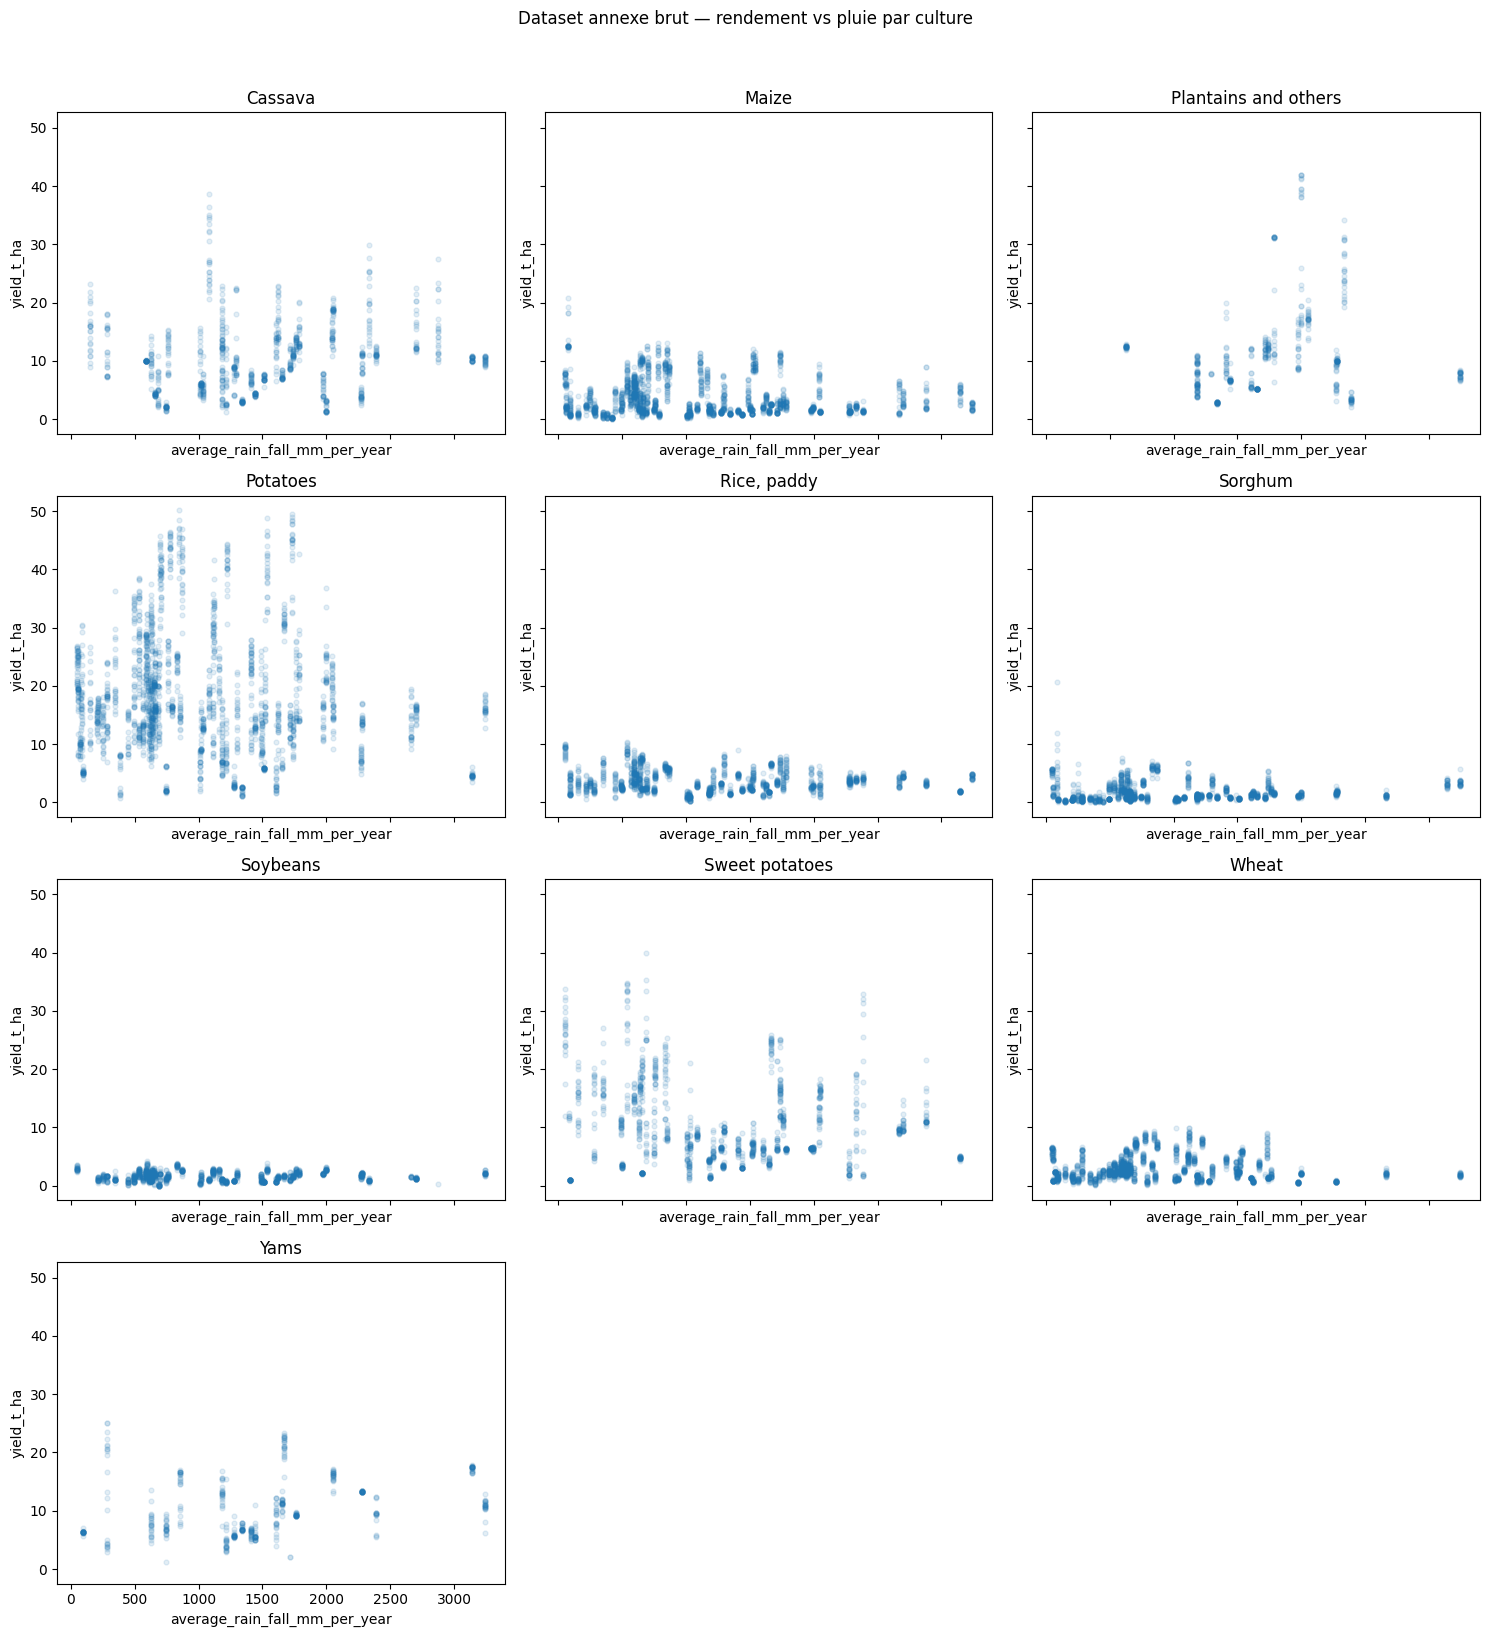

In [ ]:
items = sorted(plot_annex_top["Item"].astype(str).unique().tolist())

n_cols = 3
n_rows = int(np.ceil(len(items) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, item_name in zip(axes, items):
    sub = plot_annex_top[plot_annex_top["Item"] == item_name].copy()
    ax.scatter(
        sub["average_rain_fall_mm_per_year"],
        sub["yield_t_ha"],
        alpha=0.12,
        s=12,
    )
    ax.set_title(item_name)
    ax.set_xlabel("average_rain_fall_mm_per_year")
    ax.set_ylabel("yield_t_ha")

for ax in axes[len(items):]:
    ax.axis("off")

plt.suptitle("Dataset annexe brut — rendement vs pluie par culture", y=1.02)
plt.tight_layout()
plt.show()

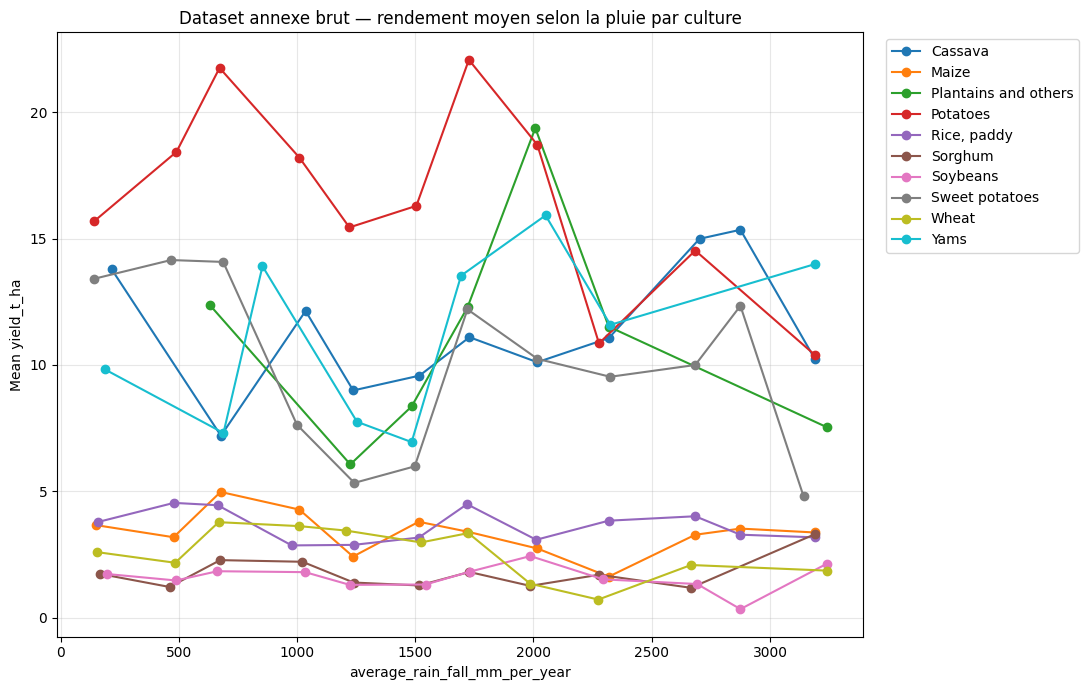

In [ ]:
n_bins = 12

plot_annex_top["rain_bin"] = pd.cut(
    plot_annex_top["average_rain_fall_mm_per_year"],
    bins=n_bins
)

binned_annex_curve = (
    plot_annex_top.groupby(["Item", "rain_bin"], observed=False)
    .agg(
        rainfall_mid=("average_rain_fall_mm_per_year", "mean"),
        yield_mean=("yield_t_ha", "mean"),
        n_obs=("yield_t_ha", "size"),
    )
    .reset_index()
)

plt.figure(figsize=(11, 7))

for item_name, sub in binned_annex_curve.groupby("Item"):
    sub = sub.sort_values("rainfall_mid")
    plt.plot(
        sub["rainfall_mid"],
        sub["yield_mean"],
        marker="o",
        label=item_name,
    )

plt.title("Dataset annexe brut — rendement moyen selon la pluie par culture")
plt.xlabel("average_rain_fall_mm_per_year")
plt.ylabel("Mean yield_t_ha")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

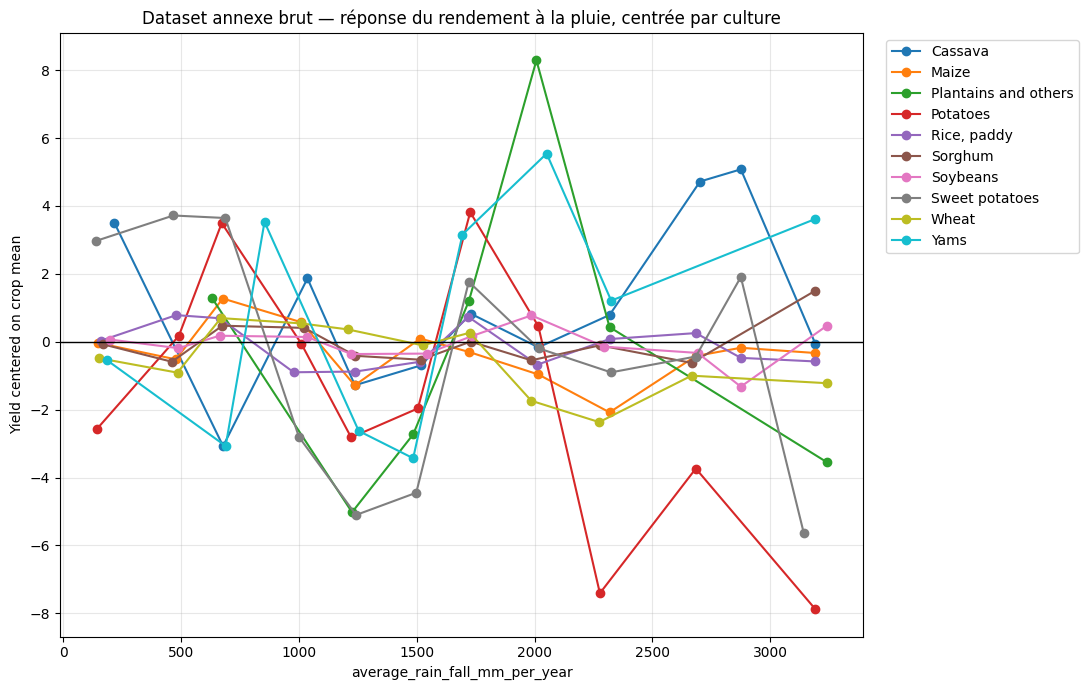

In [ ]:
item_mean_yield = (
    plot_annex_top.groupby("Item")["yield_t_ha"]
    .mean()
    .rename("item_mean_yield")
)

plot_annex_centered = plot_annex_top.merge(
    item_mean_yield,
    on="Item",
    how="left"
)

plot_annex_centered["yield_centered"] = (
    plot_annex_centered["yield_t_ha"] - plot_annex_centered["item_mean_yield"]
)

plot_annex_centered["rain_bin"] = pd.cut(
    plot_annex_centered["average_rain_fall_mm_per_year"],
    bins=n_bins
)

binned_annex_centered_curve = (
    plot_annex_centered.groupby(["Item", "rain_bin"], observed=False)
    .agg(
        rainfall_mid=("average_rain_fall_mm_per_year", "mean"),
        yield_centered_mean=("yield_centered", "mean"),
        n_obs=("yield_centered", "size"),
    )
    .reset_index()
)

plt.figure(figsize=(11, 7))

for item_name, sub in binned_annex_centered_curve.groupby("Item"):
    sub = sub.sort_values("rainfall_mid")
    plt.plot(
        sub["rainfall_mid"],
        sub["yield_centered_mean"],
        marker="o",
        label=item_name,
    )

plt.axhline(0, color="black", linewidth=1)
plt.title("Dataset annexe brut — réponse du rendement à la pluie, centrée par culture")
plt.xlabel("average_rain_fall_mm_per_year")
plt.ylabel("Yield centered on crop mean")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
summary_annex_raw = (
    plot_annex_top.groupby("Item")
    .agg(
        n_obs=("yield_t_ha", "size"),
        rainfall_mean=("average_rain_fall_mm_per_year", "mean"),
        rainfall_std=("average_rain_fall_mm_per_year", "std"),
        yield_mean=("yield_t_ha", "mean"),
        yield_std=("yield_t_ha", "std"),
    )
    .sort_values("yield_mean", ascending=False)
)

display(summary_annex_raw)

,n_obs,rainfall_mean,rainfall_std,yield_mean,yield_std
Item,,,,,
Potatoes,2091,1022.987566,696.646361,18.260182,10.110702
Plantains and others,464,1765.581897,563.177005,11.083792,7.709545
Sweet potatoes,1163,1301.619948,751.163299,10.431653,7.036605
Yams,454,1498.458150,805.048552,10.375882,4.983395
Cassava,941,1533.341126,730.646349,10.270532,5.888570
"Rice, paddy",1502,1221.097204,780.586062,3.754165,1.934939
Maize,2028,1105.724852,744.973991,3.698035,3.122026
Wheat,1810,906.194475,616.010420,3.078299,2.067035
Sorghum,1435,1025.703136,726.427015,1.799532,1.627284
